<a href="https://colab.research.google.com/github/m3llad0/fake-news-detection-in-spanish-media/blob/main/Fake_news_detection_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake news detection model

Model to detected fake news in Spanish using BETO

In [1]:
!pip install torch-geometric



In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW # Import AdamW
from torch_geometric.utils import dense_to_sparse # Import dense_to_sparse
from torch_geometric.nn import GATConv # Import GATConv

import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, label_binarize
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

import numpy as np
import pandas as pd

import gc
import requests

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from textblob import TextBlob
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc


In [3]:
# Dispositivo (GPU si disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


Using: cuda


In [4]:
# API endpoint
ROUTE = "https://fake-news-data-extraction.onrender.com/dataset"

# Fetch the data
response = requests.get(ROUTE)
data = response.json()

# Extract 'Scrapped news' list
news_items = data["Scrapped news"]

# Convert to DataFrame
df = pd.DataFrame(news_items)

# Preprocess the dataset for model input
df['label'] = df['VERACIDAD'].map({'true': 0, 'false': 1, "satira":2})  # Map veracity to binary labels


df.drop(["METADATA", "VERACIDAD"], axis=1, inplace=True)

df.head()


,AUTOR,CORPUS,FECHA,TITULO,URL,label
0,Heraldo De Aragón,La Universidad de Oxford lanza en España su nu...,2017-04-05 00:00:00,Oxford lanza sus propios exámenes de certifica...,https://www.heraldo.es/noticias/sociedad/2017/...,0
1,Ernesto Agudo,"Darío Villanueva, director de la RAE, en una r...",2018-06-26 13:51:37+02:00,La RAE estudia incluir «machirulo» en el Dicci...,https://www.abc.es/cultura/abci-estudia-inclui...,0
2,"Pedro, Villa Y Caña, Pedro Villa Y Caña, Ver P...",Estudiantes de la F acultad de Ciencias Políti...,,Realizan paro en Facultad de Ciencias Política...,http://www.eluniversal.com.mx/nacion/sociedad/...,0
3,Dios De La Guerra Y Referente Del Humor Period...,This post has already been read 3168 times!\n\...,2018-01-18 08:47:27+00:00,Deniegan el B1 a un joven mudo por no poder ap...,https://haynoticia.es/deniegan-b1-joven-mudo-n...,1
4,"Redacción El Universal, Ver Perfil",Los granos de maíz que fueron tostados en el c...,,"mole, tradicional, familia, nahua, discriminad...",http://www.eluniversal.com.mx/orgullomexicano/...,0


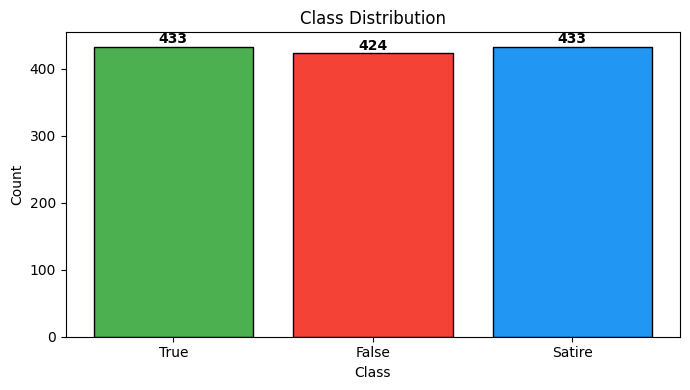

label
True      433
Satire    433
False     424
Name: count, dtype: int64


In [5]:
import matplotlib.pyplot as plt

label_names = {0: 'True', 1: 'False', 2: 'Satire'}
counts = df['label'].value_counts().sort_index()

plt.figure(figsize=(7, 4))
bars = plt.bar(
    [label_names[i] for i in counts.index],
    counts.values,
    color=['#4CAF50', '#F44336', '#2196F3'],
    edgecolor='black'
)

# Annotate counts on top of each bar
for bar, count in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             str(count), ha='center', va='bottom', fontweight='bold')

plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Also print a summary
print(df['label'].value_counts().rename(index=label_names))

# Data augmentation




In [6]:
from transformers import pipeline
import random, pandas as pd, requests

# Load BETO masked LM
fill_mask = pipeline("fill-mask", model="dccuchile/bert-base-spanish-wwm-cased", top_k=3)

def augment_text(text, mask_prob=0.15):
    """Replace ~15% of words with BETO predictions."""
    words = text.split()
    if len(words) < 5: return text
    n = max(1, int(len(words) * mask_prob))
    for i in random.sample(range(len(words)), n):
        words[i] = "[MASK]"
    masked = " ".join(words)
    try:
        preds = fill_mask(masked)
        if isinstance(preds, list):
            for p in preds:
                masked = masked.replace("[MASK]", p['token_str'], 1)
        return masked
    except:
        return text

# Apply augmentation to 30% of dataset (skip satire if desired)
subset = df[df["label"] != 2].sample(frac=0.3, random_state=42)
aug_df = subset.copy()
aug_df["CORPUS"] = aug_df["CORPUS"].apply(augment_text)

# Merge and shuffle
df = pd.concat([df, aug_df], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"✅ Data Augmentation complete: added {len(aug_df)} samples (total {len(df)})")
df.head()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Token indices sequence length is longer than the specified maximum sequence length for this mod

✅ Data Augmentation complete: added 257 samples (total 1547)


,AUTOR,CORPUS,FECHA,TITULO,URL,label
0,"Efe, Foto","LONDRES.\n\nLa última teoría científica, sobre...",2018-05-02 14:47:59-06:00,Publican la última teoría de Stephen Hawking,https://www.excelsior.com.mx/global/publican-l...,0
1,"Aitor Tilla, Gabriela Serafino, Juan Pablo Seg...",La procrastinación está considerada como una d...,2013-11-19 12:16:54+00:00,La Procrastinación será ilegal,http://lavozpopular.com/procrastinacion-sera-i...,2
2,"Oso Rulo, Escrito Por",¿No puedes pasar cinco minutos sin hacer el ri...,2018-04-30 00:00:00,"¡Hazte a un lado, Ventaneando! Los de Hoy se h...",https://eldeforma.com/2018/04/30/hazte-un-lado...,2
3,Rocío Niebla,El embarazo es parte de nuestra sexualidad y v...,2021-02-12 00:00:00,Sexo durante el embarazo: esto es todo lo que ...,https://elpais.com/mamas-papas/2021-02-12/sexo...,0
4,"Gustavo Rugeles, Director De El Expediente",A comienzos de éste año todos los medios de co...,2019-10-02 15:39:08+00:00,"Video: redadas en el banco Vaticano, el Diacon...",https://elexpediente.co/video-redadas-el-banco...,1


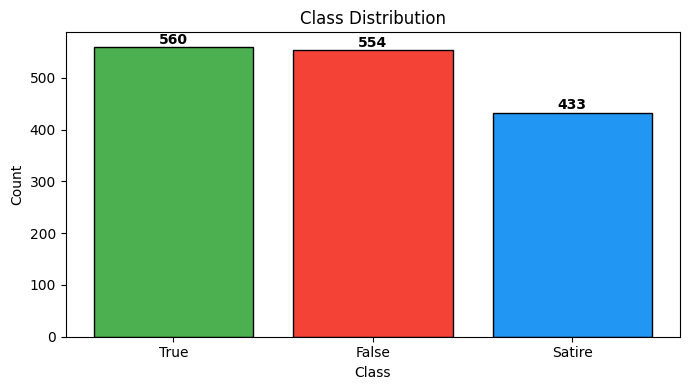

label
True      560
False     554
Satire    433
Name: count, dtype: int64


In [7]:
import matplotlib.pyplot as plt

label_names = {0: 'True', 1: 'False', 2: 'Satire'}
counts = df['label'].value_counts().sort_index()

plt.figure(figsize=(7, 4))
bars = plt.bar(
    [label_names[i] for i in counts.index],
    counts.values,
    color=['#4CAF50', '#F44336', '#2196F3'],
    edgecolor='black'
)

# Annotate counts on top of each bar
for bar, count in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             str(count), ha='center', va='bottom', fontweight='bold')

plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Also print a summary
print(df['label'].value_counts().rename(index=label_names))

In [8]:

def sentiment(x):
    return TextBlob(str(x)).sentiment.polarity


In [9]:
from transformers import TextClassificationPipeline, AutoModelForSequenceClassification

cb_tok = AutoTokenizer.from_pretrained("taniwasl/clickbait_es")
cb_mod = AutoModelForSequenceClassification.from_pretrained("taniwasl/clickbait_es")
cb_pipe = TextClassificationPipeline(model=cb_mod, tokenizer=cb_tok, top_k=None)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [10]:
from urllib.parse import urlparse
import numpy as np
import pandas as pd
import re


def type_token_ratio(text):
    tokens = text.split()
    if len(tokens) == 0:
        return 0
    return len(set(tokens)) / len(tokens)

def caps_ratio(text):
    caps = sum(1 for c in text if c.isupper())
    return caps / max(len(text),1)

def excl_ratio(text):
    excl = text.count('!')
    return excl / max(len(text),1)

def clickbait_score(txt):
    res = cb_pipe(txt[:256])[0]
    return [x for x in res if "click" in x['label'].lower()][0]['score']

In [11]:
from urllib.parse import urlparse
import numpy as np
import pandas as pd
import re

df['longitud'] = df['CORPUS'].str.split().str.len().astype(float)
df['polarity'] = df['CORPUS'].apply(sentiment)
df['clickbait'] = df['TITULO'].apply(clickbait_score)
df['fuente'] = df['AUTOR'].fillna("desconocido")
df['domain'] = df['URL'].apply(lambda x: urlparse(x).netloc)

# Explicitly convert 'FECHA' to datetime with error handling and UTC
df['FECHA'] = pd.to_datetime(df['FECHA'], errors='coerce', utc=True)
df['year']    = df['FECHA'].dt.year.fillna(0).astype(int) # Fill NaT with 0 and cast to int
df['month']   = df['FECHA'].dt.month.fillna(0).astype(int) # Fill NaT with 0 and cast to int


df['title_len']  = df['TITULO'].str.len()
df['title_excl'] = df['TITULO'].str.count('!')

df['ttr']        = df['CORPUS'].apply(type_token_ratio)
df['caps_ratio'] = df['CORPUS'].apply(caps_ratio)
df['excl_ratio'] = df['CORPUS'].apply(excl_ratio)

In [12]:
tokenizer = AutoTokenizer.from_pretrained(
    "dccuchile/bert-base-spanish-wwm-cased"
)

In [13]:
def get_cls_embeddings(texts, model, batch=8):
    enc = tokenizer(list(texts), truncation=True, padding=True, max_length=256, return_tensors='pt')
    ds = torch.utils.data.TensorDataset(enc['input_ids'], enc['attention_mask'])
    dl = torch.utils.data.DataLoader(ds, batch_size=batch)

    model.eval()
    out = []
    with torch.no_grad():
        for ix,mask in dl:
            ix,mask = ix.to(device),mask.to(device)
            h = model(input_ids=ix, attention_mask=mask)
            out.append(h.last_hidden_state[:,0,:].cpu().numpy())
    return np.vstack(out)


In [14]:
# class HybridGAT(nn.Module):
#     def __init__(self, meta_dim, text_dim=768, hidden=64):
#         super().__init__()
#         self.meta_fc = nn.Linear(meta_dim, 64)
#         self.gat = GATConv(64, 32, heads=2, concat=False)
#         self.fc1 = nn.Linear(text_dim + 32, hidden)
#         self.fc2 = nn.Linear(hidden, 3)
#         self.drop = nn.Dropout(0.5)

#     def forward(self, meta, txt, edge_index):
#         m = F.relu(self.meta_fc(meta))
#         m = self.gat(m, edge_index)
#         x = torch.cat([m, txt], dim=1)
#         x = F.relu(self.fc1(x))
#         x = self.drop(x)
#         return self.fc2(x)


In [15]:
class HybridGAT(nn.Module):
    def __init__(self, meta_dim=0):
        super().__init__()

        # GAT input: 768 dims (BETO CLS vector)
        self.gat1 = GATConv(768, 64, heads=4, concat=True)
        self.gat2 = GATConv(64*4, 64, heads=1, concat=False)

        # texto-only = 64 -> 3 clases
        self.cls = nn.Linear(64, 3)

        # si en el futuro usas metadata
        if meta_dim > 0:
            self.meta_fc = nn.Linear(meta_dim, 32)
            self.cls = nn.Linear(64 + 32, 3)

        self.meta_dim = meta_dim

    def forward(self, meta, text, edge_index):

        # --- rama texto ---
        x = self.gat1(text, edge_index)
        x = F.relu(x)
        x = self.gat2(x, edge_index)
        x = F.relu(x)

        # --- rama metadata (opcional) ---
        if self.meta_dim > 0 and meta is not None:
            m = self.meta_fc(meta)
            m = F.relu(m)
            x = torch.cat([x, m], dim=1)

        out = self.cls(x)
        return out

In [16]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, logits, targets):
        # logits: (N, C) sin softmax
        # targets: (N,)
        ce = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce)  # prob. bien clasificada
        focal = (1 - pt)**self.gamma * ce

        if self.alpha is not None:
            focal = self.alpha * focal

        if self.reduction == 'mean':
            return focal.mean()
        elif self.reduction == 'sum':
            return focal.sum()
        return focal

In [17]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from torch_geometric.utils import dense_to_sparse

import matplotlib.pyplot as plt

skf = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)

acc_scores = []
f1_scores  = []
all_preds = []
all_trues = []
all_probs = []

# PARA LEARNING CURVES GLOBALES
fold_train_curves = []
fold_val_curves = []

y = df['label'].values

for fold, (train_idx, test_idx) in enumerate(skf.split(df, y)):

    print(f"\n=== Fold {fold+1} ===")

    df_tr = df.iloc[train_idx].copy()
    df_te = df.iloc[test_idx].copy()

    # =======================
    # CV-SAFE ENCODERS
    # =======================
    le_domain = LabelEncoder().fit(df_tr['domain'])
    df_tr['domain_enc'] = le_domain.transform(df_tr['domain'])
    df_te['domain_enc'] = df_te['domain'].map(lambda x: le_domain.transform([x])[0] if x in le_domain.classes_ else -1)

    le_autor = LabelEncoder().fit(df_tr['AUTOR'])
    df_tr['autor_enc'] = le_autor.transform(df_tr['AUTOR'])
    df_te['autor_enc'] = df_te['AUTOR'].map(lambda x: le_autor.transform([x])[0] if x in le_autor.classes_ else -1)

    le_corpus = LabelEncoder().fit(df_tr['CORPUS'])
    df_tr['corpus_enc'] = le_corpus.transform(df_tr['CORPUS'])
    df_te['corpus_enc'] = df_te['CORPUS'].map(lambda x: le_corpus.transform([x])[0] if x in le_corpus.classes_ else -1)

    # =======================
    # METADATA NUMÉRICA
    # =======================
    meta_cols = [
        'domain_enc','autor_enc','corpus_enc',
        'year','month',
        'longitud','polarity','clickbait',
        'title_len','title_excl',
        'excl_ratio','caps_ratio','ttr'
    ]

    scaler = MinMaxScaler().fit(df_tr[meta_cols])
    Xtr_meta = scaler.transform(df_tr[meta_cols])
    Xte_meta = scaler.transform(df_te[meta_cols])

    # =======================
    # TOKENIZACIÓN
    # =======================
    tr_enc = tokenizer(list(df_tr['CORPUS']), truncation=True, padding=True, max_length=256, return_tensors="pt").to(device)
    te_enc = tokenizer(list(df_te['CORPUS']), truncation=True, padding=True, max_length=256, return_tensors="pt").to(device)

    ytr = torch.tensor(df_tr['label'].values, dtype=torch.long).to(device)
    yte = torch.tensor(df_te['label'].values, dtype=torch.long).to(device)

    # =======================
    # BETO
    # =======================
    beto = AutoModel.from_pretrained("dccuchile/bert-base-spanish-wwm-cased").to(device)

    # congela capas inferiores
    for name, param in beto.named_parameters():
        if any(f"encoder.layer.{i}" in name for i in range(6)):
            param.requires_grad = False

    cls_head = nn.Linear(768, 3).to(device)
    opt = AdamW(list(beto.parameters()) + list(cls_head.parameters()), lr=2e-5)
    crit = nn.CrossEntropyLoss(label_smoothing=0.1)

    train_loader = DataLoader(
        TensorDataset(tr_enc['input_ids'], tr_enc['attention_mask'], ytr),
        batch_size=8, shuffle=True
    )

    scaler = torch.cuda.amp.GradScaler()

    # === TRAIN BETO ===
    beto.train(); cls_head.train()

    for epoch in range(3):
        for input_ids, attn, labels in train_loader:
            opt.zero_grad()
            with torch.cuda.amp.autocast():
                out = beto(input_ids=input_ids, attention_mask=attn)
                cls_vec = out.last_hidden_state[:,0,:]
                logits = cls_head(cls_vec)
                loss = crit(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

    # =======================
    # EXTRAER EMBEDDINGS
    # =======================
    beto.eval(); cls_head.eval()

    with torch.no_grad():
        Xtr_txt = beto(**tr_enc).last_hidden_state[:,0,:].cpu().numpy()
        Xte_txt = beto(**te_enc).last_hidden_state[:,0,:].cpu().numpy()

    X_all_txt = np.vstack([Xtr_txt, Xte_txt])
    meta_all  = np.vstack([Xtr_meta, Xte_meta])


    # =======================
    # MULTI-VIEW GRAPH
    # =======================
    sim_text = cosine_similarity(X_all_txt) ** 2
    sim_domain = (np.equal.outer(meta_all[:,0], meta_all[:,0])).astype(np.float32)
    sim_time   = (np.abs(np.subtract.outer(meta_all[:,3], meta_all[:,3])) <= 1).astype(np.float32)

    sim = (sim_text + sim_domain + sim_time) / 3.0

    np.fill_diagonal(sim, 0)
    sim = np.maximum(sim, sim.T)

    # k-NN
    k = 8
    idx = np.argsort(sim, axis=1)[:, :-k]
    for i, rows in enumerate(idx):
        sim[i, rows] = 0

    adj = torch.tensor(sim, dtype=torch.float32)
    edge_index, _ = dense_to_sparse(adj)
    edge_index = edge_index.to(device)

    # =======================
    # TENSORES
    # =======================
    t_all    = torch.tensor(X_all_txt, dtype=torch.float32).to(device)
    meta_all = torch.tensor(meta_all, dtype=torch.float32).to(device)
    y_all    = torch.tensor(np.concatenate([df_tr['label'], df_te['label']]), dtype=torch.long).to(device)

    num_train = len(df_tr)
    train_nodes = torch.arange(num_train, device=device)
    test_nodes  = torch.arange(num_train, num_train + len(df_te), device=device)

    # =======================
    # HybridGAT
    # =======================
    model = HybridGAT(meta_dim=meta_all.shape[1]).to(device)
    gnn_opt = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
    crit2 = nn.CrossEntropyLoss(label_smoothing=0.1)

    # ====== ARRAYS PARA CURVAS ======
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    # =======================
    # TRAIN GNN
    # =======================
    for epoch in range(12):
        model.train()
        gnn_opt.zero_grad()
        logits = model(meta_all, t_all, edge_index)[train_nodes]
        loss2 = crit2(logits, y_all[train_nodes])

        # Train accuracy
        pred_train = logits.argmax(dim=1)
        acc_train = accuracy_score(y_all[train_nodes].cpu(), pred_train.cpu())

        loss2.backward()
        gnn_opt.step()

        # VALIDACIÓN
        model.eval()
        with torch.no_grad():
            logits_v = model(meta_all, t_all, edge_index)[test_nodes]
            loss_v = crit2(logits_v, y_all[test_nodes])
            pred_v = logits_v.argmax(dim=1)
            acc_v = accuracy_score(y_all[test_nodes].cpu(), pred_v.cpu())

        train_losses.append(loss2.item())
        val_losses.append(loss_v.item())
        train_accs.append(acc_train)
        val_accs.append(acc_v)

    fold_train_curves.append((train_losses, val_losses))

    # =======================
    # FINAL TEST
    # =======================
    model.eval()
    with torch.no_grad():
        logits_te = model(meta_all, t_all, edge_index)[test_nodes]
        pred = logits_te.argmax(dim=1).cpu().numpy()
        probs = logits_te.softmax(dim=1).cpu().numpy()
        true = y_all[test_nodes].cpu().numpy()

    acc = accuracy_score(true, pred)
    f1  = f1_score(true, pred, average='macro')

    acc_scores.append(acc)
    f1_scores.append(f1)

    all_preds.extend(pred)
    all_trues.extend(true)
    all_probs.append(probs)

    print(f"Acc={acc:.3f}  F1={f1:.3f}")

    # limpieza
    del beto, cls_head, model, sim
    del tr_enc, te_enc, train_loader
    torch.cuda.empty_cache()
    gc.collect()


# =======================
# MÉTRICAS FINALES
# =======================
all_probs = np.vstack(all_probs)
all_trues = np.array(all_trues)
y_bin = label_binarize(all_trues, classes=[0,1,2])

roc_macro = roc_auc_score(y_bin, all_probs, average='macro', multi_class='ovr')

print("\nAUC-ROC (macro):", round(roc_macro,4))
print("\nAccuracy CV:", np.mean(acc_scores), "±", np.std(acc_scores))
print("Macro-F1 CV:", np.mean(f1_scores), "±", np.std(f1_scores))



=== Fold 1 ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on 

Acc=0.954  F1=0.954

=== Fold 2 ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on 

Acc=0.917  F1=0.920

=== Fold 8 ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on 

Acc=0.902  F1=0.902

AUC-ROC (macro): 0.9857

Accuracy CV: 0.9243463223118422 ± 0.018717527094613738
Macro-F1 CV: 0.9262124240634484 ± 0.018132035651220693


In [18]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

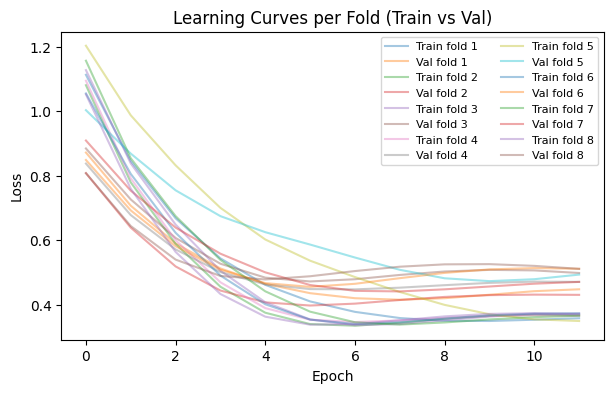

In [19]:
plt.figure(figsize=(7,4))
for i,(tr,vl) in enumerate(fold_train_curves):
    plt.plot(tr, alpha=0.4, label=f'Train fold {i+1}')
    plt.plot(vl, alpha=0.4, label=f'Val fold {i+1}')
plt.title("Learning Curves per Fold (Train vs Val)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(ncol=2, fontsize=8)
plt.show()


<Figure size 500x500 with 0 Axes>

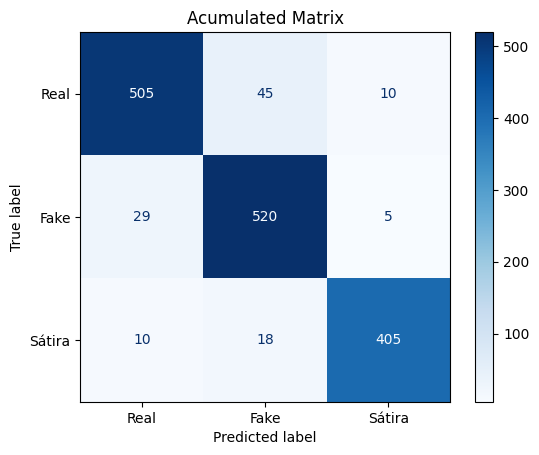

In [20]:
cm = confusion_matrix(all_trues, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Real","Fake","Sátira"])
plt.figure(figsize=(5,5))
disp.plot(cmap='Blues')
plt.title("Acumulated Matrix")
plt.grid(False)
plt.show()


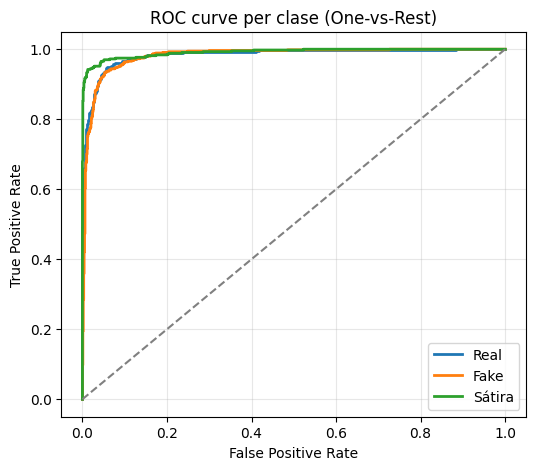

In [21]:
plt.figure(figsize=(6,5))

for i, cls in enumerate(["Real","Fake","Sátira"]):
    fpr, tpr, _ = roc_curve(y_bin[:,i], all_probs[:,i])
    plt.plot(fpr, tpr, lw=2, label=f"{cls}")

plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve per clase (One-vs-Rest)")
plt.legend()
plt.grid(alpha=.3)
plt.show()


/tmp/ipykernel_21939/1711007803.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([acc_scores, f1_scores], labels=["Accuracy","Macro-F1"])


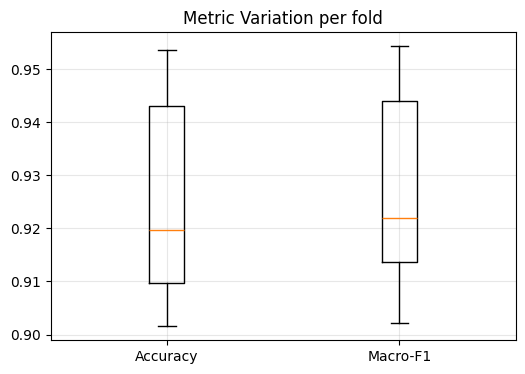

In [22]:
plt.figure(figsize=(6,4))
plt.boxplot([acc_scores, f1_scores], labels=["Accuracy","Macro-F1"])
plt.title("Metric Variation per fold")
plt.grid(alpha=0.3)
plt.show()


In [23]:
print("\n🚀 Retraining final model on full dataset...")

# Re-encode categorical variables
le_domain = LabelEncoder().fit(df['domain'])
le_autor  = LabelEncoder().fit(df['AUTOR'])
le_corpus = LabelEncoder().fit(df['CORPUS'])
df['domain_enc'] = le_domain.transform(df['domain'])
df['autor_enc']  = le_autor.transform(df['AUTOR'])
df['corpus_enc'] = le_corpus.transform(df['CORPUS'])

# Metadata
meta_cols = [
    'domain_enc','autor_enc','corpus_enc',
    'year','month',
    'longitud','polarity','clickbait',
    'title_len','title_excl',
    'excl_ratio','caps_ratio','ttr'
]
scaler = MinMaxScaler().fit(df[meta_cols])
X_meta = scaler.transform(df[meta_cols])

# BETO tokenization & embeddings
tokenizer = AutoTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")
enc = tokenizer(list(df['CORPUS']), truncation=True, padding=True, max_length=256, return_tensors="pt").to(device)
y_all = torch.tensor(df['label'].values, dtype=torch.long).to(device)

beto = AutoModel.from_pretrained("dccuchile/bert-base-spanish-wwm-cased").to(device)
for name, p in beto.named_parameters():
    if any(f"encoder.layer.{i}" in name for i in range(6)):
        p.requires_grad = False

cls_head = nn.Linear(768, 3).to(device)
opt = AdamW(list(beto.parameters()) + list(cls_head.parameters()), lr=2e-5)
crit = nn.CrossEntropyLoss(label_smoothing=0.1)

train_loader = DataLoader(TensorDataset(enc['input_ids'], enc['attention_mask'], y_all),
                          batch_size=8, shuffle=True)
scaler_amp = torch.cuda.amp.GradScaler()

beto.train(); cls_head.train()
for epoch in range(3):
    for input_ids, attn, labels in train_loader:
        opt.zero_grad()
        with torch.cuda.amp.autocast():
            out = beto(input_ids=input_ids, attention_mask=attn)
            cls_vec = out.last_hidden_state[:, 0, :]
            logits = cls_head(cls_vec)
            loss = crit(logits, labels)
        scaler_amp.scale(loss).backward()
        scaler_amp.step(opt)
        scaler_amp.update()

# Extract embeddings for graph
beto.eval()
with torch.no_grad():
    X_txt = beto(**enc).last_hidden_state[:, 0, :].cpu().numpy()

# Build similarity graph
sim_text = cosine_similarity(X_txt) ** 2
sim_domain = (np.equal.outer(X_meta[:,0], X_meta[:,0])).astype(np.float32)
sim_time   = (np.abs(np.subtract.outer(X_meta[:,3], X_meta[:,3])) <= 1).astype(np.float32)
sim = (sim_text + sim_domain + sim_time) / 3.0
np.fill_diagonal(sim, 0)
sim = np.maximum(sim, sim.T)

# Keep strongest k edges
k = 8
for i in range(sim.shape[0]):
    weakest = np.argsort(sim[i])[:-k]
    sim[i, weakest] = 0

adj = torch.tensor(sim, dtype=torch.float32)
edge_index, _ = dense_to_sparse(adj)
edge_index = edge_index.to(device)

# Train GNN
t_all = torch.tensor(X_txt, dtype=torch.float32).to(device)
meta_all = torch.tensor(X_meta, dtype=torch.float32).to(device)

model = HybridGAT(meta_dim=meta_all.shape[1]).to(device)
opt_gnn = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
crit_gnn = nn.CrossEntropyLoss(label_smoothing=0.1)

for epoch in range(12):
    model.train()
    opt_gnn.zero_grad()
    logits = model(meta_all, t_all, edge_index)
    loss = crit_gnn(logits, y_all)
    loss.backward()
    opt_gnn.step()

print("✅ Final model trained successfully!")



🚀 Retraining final model on full dataset...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on 

✅ Final model trained successfully!


# Pruebas del modelo

In [24]:

import pickle
from datetime import datetime
from urllib.parse import urlparse
from pathlib import Path
from typing import List, Dict, Union, Tuple, Optional

class FakeNewsClassifier:
    """
    Hybrid GNN-BETO Fake News Classifier

    A complete classifier that combines BETO (Spanish BERT) for text understanding
    with Graph Attention Networks (GAT) for contextual information propagation.

    Attributes:
        device (torch.device): Computing device (CPU or CUDA)
        model (HybridGAT): Trained GNN model
        beto (AutoModel): Fine-tuned BETO model
        tokenizer (AutoTokenizer): BETO tokenizer
        clickbait_pipeline: Clickbait detection pipeline
        label_encoders (dict): Label encoders for categorical features
        scaler (MinMaxScaler): Feature scaler
        train_embeddings (dict): Training data embeddings and features
        trained_graph (torch.Tensor): Original trained graph structure
        label_map (dict): Mapping from numeric labels to text
    """

    def __init__(self, device: Optional[torch.device] = None):
        """
        Initialize the classifier.

        Parameters:
            device: Computing device. If None, automatically selects CUDA if available.
        """
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"🖥️  Using device: {self.device}")

        # Model components (to be loaded)
        self.model = None
        self.beto = None
        self.tokenizer = None
        self.clickbait_pipeline = None

        # Preprocessing components
        self.label_encoders = {
            'domain': None,
            'autor': None,
            'corpus': None
        }
        self.scaler = None

        # Training data (for graph extension)
        self.train_embeddings = {
            'text': None,
            'meta': None
        }
        self.trained_graph = None

        # Label mapping
        self.label_map = {0: 'Real', 1: 'Fake', 2: 'Sátira'}
        self.reverse_label_map = {'Real': 0, 'Fake': 1, 'Sátira': 2}

        # Metadata columns (must match training)
        self.meta_cols = [
            'domain_enc', 'autor_enc', 'corpus_enc',
            'year', 'month',
            'longitud', 'polarity', 'clickbait',
            'title_len', 'title_excl',
            'excl_ratio', 'caps_ratio', 'ttr'
        ]

    # =========================================================================
    # Model Management
    # =========================================================================

    def save(self, save_dir: Union[str, Path]) -> None:
        """
        Save all model components to directory.

        Parameters:
            save_dir: Directory path to save model components
        """
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

        # Save model weights
        torch.save(self.model.state_dict(), save_dir / 'hybrid_gat_model.pth')
        torch.save(self.beto.state_dict(), save_dir / 'beto_finetuned.pth')

        # Save preprocessing components
        components = {
            'le_domain': self.label_encoders['domain'],
            'le_autor': self.label_encoders['autor'],
            'le_corpus': self.label_encoders['corpus'],
            'scaler': self.scaler,
            'train_text_embeddings': self.train_embeddings['text'],
            'train_meta_features': self.train_embeddings['meta'],
            'trained_edge_index': self.trained_graph.cpu() if self.trained_graph is not None else None,
            'meta_dim': self.train_embeddings['meta'].shape[1] if self.train_embeddings['meta'] is not None else 0
        }

        with open(save_dir / 'model_components.pkl', 'wb') as f:
            pickle.dump(components, f)

        print(f"✅ Model saved successfully to {save_dir}")

    def load(self, load_dir: Union[str, Path], model_class) -> None:
        """
        Load all model components from directory.

        Parameters:
            load_dir: Directory path containing model components
            model_class: HybridGAT class definition (needed to instantiate model)
        """
        load_dir = Path(load_dir)

        # Load preprocessing components
        with open(load_dir / 'model_components.pkl', 'rb') as f:
            components = pickle.load(f)

        self.label_encoders['domain'] = components['le_domain']
        self.label_encoders['autor'] = components['le_autor']
        self.label_encoders['corpus'] = components['le_corpus']
        self.scaler = components['scaler']
        self.train_embeddings['text'] = components['train_text_embeddings']
        self.train_embeddings['meta'] = components['train_meta_features']
        self.trained_graph = components['trained_edge_index']
        meta_dim = components['meta_dim']

        # Load tokenizer
        self.tokenizer = AutoTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")

        # Load clickbait pipeline
        cb_tok = AutoTokenizer.from_pretrained("taniwasl/clickbait_es")
        cb_mod = AutoModelForSequenceClassification.from_pretrained("taniwasl/clickbait_es")
        self.clickbait_pipeline = TextClassificationPipeline(
            model=cb_mod, tokenizer=cb_tok, return_all_scores=True
        )

        # Load BETO
        self.beto = AutoModel.from_pretrained("dccuchile/bert-base-spanish-wwm-cased").to(self.device)
        self.beto.load_state_dict(torch.load(load_dir / 'beto_finetuned.pth', map_location=self.device))
        self.beto.eval()

        # Load GNN model
        self.model = model_class(meta_dim=meta_dim).to(self.device)
        self.model.load_state_dict(torch.load(load_dir / 'hybrid_gat_model.pth', map_location=self.device))
        self.model.eval()

        print(f"✅ Model loaded successfully from {load_dir}")

    def initialize_from_training(self, model, beto, tokenizer, clickbait_pipeline,
                                le_domain, le_autor, le_corpus, scaler,
                                train_text_embeddings, train_meta_features,
                                trained_edge_index):
        """
        Initialize classifier with components from training session.
        Use this when you've just finished training and want to classify immediately.

        Parameters:
            model: Trained HybridGAT model
            beto: Fine-tuned BETO model
            tokenizer: BETO tokenizer
            clickbait_pipeline: Clickbait detection pipeline
            le_domain, le_autor, le_corpus: Label encoders
            scaler: Feature scaler
            train_text_embeddings: Training text embeddings
            train_meta_features: Training metadata features
            trained_edge_index: Trained graph edge indices
        """
        self.model = model
        self.beto = beto
        self.tokenizer = tokenizer
        self.clickbait_pipeline = clickbait_pipeline

        self.label_encoders['domain'] = le_domain
        self.label_encoders['autor'] = le_autor
        self.label_encoders['corpus'] = le_corpus
        self.scaler = scaler

        self.train_embeddings['text'] = train_text_embeddings
        self.train_embeddings['meta'] = train_meta_features
        self.trained_graph = trained_edge_index

        print("✅ Classifier initialized from training session")

    # =========================================================================
    # Feature Engineering
    # =========================================================================

    @staticmethod
    def _sentiment(text: str) -> float:
        """Calculate sentiment polarity."""
        return TextBlob(str(text)).sentiment.polarity

    @staticmethod
    def _type_token_ratio(text: str) -> float:
        """Calculate vocabulary diversity."""
        tokens = text.split()
        return len(set(tokens)) / len(tokens) if len(tokens) > 0 else 0

    @staticmethod
    def _caps_ratio(text: str) -> float:
        """Calculate ratio of capital letters."""
        caps = sum(1 for c in text if c.isupper())
        return caps / max(len(text), 1)

    @staticmethod
    def _excl_ratio(text: str) -> float:
        """Calculate ratio of exclamation marks."""
        return text.count('!') / max(len(text), 1)

    def _clickbait_score(self, text: str) -> float:
        """Calculate clickbait probability."""
        res = self.clickbait_pipeline(text[:256])
        return [x for x in res if "click" in x['label'].lower()][0]['score']

    def _extract_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Extract all features from raw news data.

        Parameters:
            df: DataFrame with raw news data

        Returns:
            DataFrame with extracted features
        """
        # Text-based features
        df['longitud'] = df['CORPUS'].str.split().str.len().astype(float)
        df['polarity'] = df['CORPUS'].apply(self._sentiment)
        df['clickbait'] = df['TITULO'].apply(self._clickbait_score)
        df['ttr'] = df['CORPUS'].apply(self._type_token_ratio)
        df['caps_ratio'] = df['CORPUS'].apply(self._caps_ratio)
        df['excl_ratio'] = df['CORPUS'].apply(self._excl_ratio)

        # Title features
        df['title_len'] = df['TITULO'].str.len()
        df['title_excl'] = df['TITULO'].str.count('!')

        # Source features
        df['fuente'] = df['AUTOR']
        df['domain'] = df['URL'].apply(lambda x: urlparse(x).netloc)

        # Temporal features
        df['FECHA'] = pd.to_datetime(df['FECHA'], errors='coerce')
        df['year'] = df['FECHA'].dt.year.fillna(datetime.now().year).astype(int)
        df['month'] = df['FECHA'].dt.month.fillna(datetime.now().month).astype(int)

        return df

    def _prepare_news_data(self, news_list: List[Dict]) -> pd.DataFrame:
        """
        Prepare and validate news data.

        Parameters:
            news_list: List of news dictionaries

        Returns:
            Prepared DataFrame
        """
        # Convert to DataFrame
        df = pd.DataFrame(news_list)

        # Validate required fields
        required_fields = ['TITULO', 'CORPUS']
        for field in required_fields:
            if field not in df.columns:
                raise ValueError(f"Missing required field: {field}")

        # Fill optional fields
        df['AUTOR'] = df.get('AUTOR', 'desconocido').fillna('desconocido')
        df['URL'] = df.get('URL', 'https://unknown.com').fillna('https://unknown.com')
        df['FECHA'] = df.get('FECHA', datetime.now().strftime('%Y-%m-%d'))

        # Extract features
        df = self._extract_features(df)

        return df

    def _encode_features(self, df: pd.DataFrame) -> np.ndarray:
        """
        Encode categorical features and scale numerical features.

        Parameters:
            df: DataFrame with extracted features

        Returns:
            Scaled metadata features
        """
        # Encode categorical features (handle unknown values)
        df['domain_enc'] = df['domain'].map(
            lambda x: self.label_encoders['domain'].transform([x])[0]
            if x in self.label_encoders['domain'].classes_ else -1
        )
        df['autor_enc'] = df['AUTOR'].map(
            lambda x: self.label_encoders['autor'].transform([x])[0]
            if x in self.label_encoders['autor'].classes_ else -1
        )
        df['corpus_enc'] = df['CORPUS'].map(
            lambda x: self.label_encoders['corpus'].transform([x])[0]
            if x in self.label_encoders['corpus'].classes_ else -1
        )

        # Scale features
        X_meta = self.scaler.transform(df[self.meta_cols])

        return X_meta

    def _extract_embeddings(self, df: pd.DataFrame) -> np.ndarray:
        """
        Extract BETO embeddings from text.

        Parameters:
            df: DataFrame with news text

        Returns:
            Text embeddings (CLS token representations)
        """
        # Tokenize
        enc = self.tokenizer(
            list(df['CORPUS']),
            truncation=True,
            padding=True,
            max_length=256,
            return_tensors="pt"
        ).to(self.device)

        # Extract embeddings
        self.beto.eval()
        with torch.no_grad():
            outputs = self.beto(**enc)
            embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()

        return embeddings

    # =========================================================================
    # Graph Construction
    # =========================================================================

    def _extend_graph(self, X_new_txt: np.ndarray, X_new_meta: np.ndarray,
                     k: int = 8) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Extend trained graph with new nodes.

        Parameters:
            X_new_txt: Text embeddings of new nodes
            X_new_meta: Metadata features of new nodes
            k: Number of nearest neighbors to connect

        Returns:
            Tuple of (edge_index, all_text_features, all_meta_features)
        """
        X_train_txt = self.train_embeddings['text']
        X_train_meta = self.train_embeddings['meta']

        num_train = len(X_train_txt)
        num_new = len(X_new_txt)

        # Combine all features
        X_all_txt = np.vstack([X_train_txt, X_new_txt])
        X_all_meta = np.vstack([X_train_meta, X_new_meta])

        # Calculate multi-view similarity for new nodes
        sim_text = cosine_similarity(X_new_txt, X_all_txt) ** 2
        sim_domain = np.equal.outer(X_new_meta[:, 0], X_all_meta[:, 0]).astype(np.float32)
        sim_time = (np.abs(np.subtract.outer(X_new_meta[:, 3], X_all_meta[:, 3])) <= 1).astype(np.float32)

        # Combined similarity
        sim = (sim_text + sim_domain + sim_time) / 3.0

        # Build edges for new nodes
        new_edges_src = []
        new_edges_dst = []

        for i in range(num_new):
            new_idx = num_train + i
            node_sim = sim[i, :].copy()
            node_sim[new_idx] = 0  # Don't connect to itself

            # Get k nearest neighbors
            k_nearest = np.argsort(node_sim)[-k:]

            # Add bidirectional edges
            for neighbor in k_nearest:
                if node_sim[neighbor] > 0:
                    new_edges_src.extend([new_idx, neighbor])
                    new_edges_dst.extend([neighbor, new_idx])

        # Combine with trained edges
        if len(new_edges_src) > 0:
            new_edges = torch.tensor([new_edges_src, new_edges_dst], dtype=torch.long)
            extended_edge_index = torch.cat([self.trained_graph.cpu(), new_edges], dim=1)
        else:
            extended_edge_index = self.trained_graph.cpu()

        # Convert to tensors
        t_all = torch.tensor(X_all_txt, dtype=torch.float32)
        meta_all = torch.tensor(X_all_meta, dtype=torch.float32)

        return extended_edge_index, t_all, meta_all

    # =========================================================================
    # Prediction
    # =========================================================================

    def predict(self, news_list: List[Dict], k: int = 8,
                return_probabilities: bool = True, verbose: bool = True) -> pd.DataFrame:
        """
        Classify one or multiple news articles.

        Parameters:
            news_list: List of dictionaries, each containing:
                - 'TITULO': Title of the news (required)
                - 'CORPUS': Main text/body (required)
                - 'AUTOR': Author or source (optional)
                - 'URL': URL of the news (optional)
                - 'FECHA': Date in 'YYYY-MM-DD' format (optional)
            k: Number of nearest neighbors for graph connection
            return_probabilities: Whether to include class probabilities
            verbose: Whether to print progress messages

        Returns:
            DataFrame with classification results
        """
        # Validate model is loaded
        if self.model is None or self.beto is None:
            raise RuntimeError("Model not loaded. Call load() or initialize_from_training() first.")

        if verbose:
            print(f"🔍 Classifying {len(news_list)} news article(s)...")

        # Step 1: Prepare data
        if verbose:
            print("  📝 Preparing data...")
        df = self._prepare_news_data(news_list)

        # Step 2: Encode features
        if verbose:
            print("  🔢 Encoding features...")
        X_meta = self._encode_features(df)

        # Step 3: Extract embeddings
        if verbose:
            print("  🧠 Extracting embeddings...")
        X_txt = self._extract_embeddings(df)

        # Step 4: Extend graph
        if verbose:
            print("  🕸️  Extending graph...")
        edge_index, t_all, meta_all = self._extend_graph(X_txt, X_meta, k=k)

        # Move to device
        edge_index = edge_index.to(self.device)
        t_all = t_all.to(self.device)
        meta_all = meta_all.to(self.device)

        # Step 5: Make predictions
        if verbose:
            print("  🎯 Making predictions...")

        self.model.eval()
        num_train = len(self.train_embeddings['text'])
        new_nodes = torch.arange(num_train, num_train + len(df), device=self.device)

        with torch.no_grad():
            logits = self.model(meta_all, t_all, edge_index)[new_nodes]
            probs = logits.softmax(dim=1).cpu().numpy()
            preds = logits.argmax(dim=1).cpu().numpy()

        # Step 6: Format results
        results = pd.DataFrame({
            'Title': df['TITULO'].values,
            'Prediction': [self.label_map[p] for p in preds],
            'Confidence': np.max(probs, axis=1)
        })

        if return_probabilities:
            results['Prob_Real'] = probs[:, 0]
            results['Prob_Fake'] = probs[:, 1]
            results['Prob_Satira'] = probs[:, 2]

        if verbose:
            print("✅ Classification complete!\n")

        return results

    def predict_single(self, titulo: str, corpus: str,
                      autor: Optional[str] = None,
                      url: Optional[str] = None,
                      fecha: Optional[str] = None,
                      verbose: bool = True) -> Dict:
        """
        Classify a single news article with convenient interface.

        Parameters:
            titulo: Title of the news
            corpus: Main text/body
            autor: Author or source (optional)
            url: URL of the news (optional)
            fecha: Date in 'YYYY-MM-DD' format (optional)
            verbose: Whether to print progress

        Returns:
            Dictionary with classification results
        """
        news = [{
            'TITULO': titulo,
            'CORPUS': corpus,
            'AUTOR': autor or 'desconocido',
            'URL': url or 'https://unknown.com',
            'FECHA': fecha or datetime.now().strftime('%Y-%m-%d')
        }]

        result = self.predict(news, verbose=verbose)

        return {
            'prediction': result['Prediction'].iloc[0],
            'confidence': float(result['Confidence'].iloc[0]),
            'probabilities': {
                'Real': float(result['Prob_Real'].iloc[0]),
                'Fake': float(result['Prob_Fake'].iloc[0]),
                'Sátira': float(result['Prob_Satira'].iloc[0])
            }
        }

    # =========================================================================
    # Utility Methods
    # =========================================================================

    def get_model_info(self) -> Dict:
        """Get information about the loaded model."""
        if self.model is None:
            return {"status": "Model not loaded"}

        return {
            "status": "Model loaded",
            "device": str(self.device),
            "training_samples": len(self.train_embeddings['text']) if self.train_embeddings['text'] is not None else 0,
            "graph_edges": self.trained_graph.shape[1] if self.trained_graph is not None else 0,
            "classes": list(self.label_map.values())
        }

    def __repr__(self) -> str:
        info = self.get_model_info()
        return f"FakeNewsClassifier(status='{info['status']}', device='{info.get('device', 'N/A')}')"



In [25]:
classifier = FakeNewsClassifier(device=device)
classifier.initialize_from_training(
    model=model,
    beto=beto,
    tokenizer=tokenizer,
    clickbait_pipeline=cb_pipe,
    le_domain=le_domain,
    le_autor=le_autor,
    le_corpus=le_corpus,
    scaler=scaler,
    train_text_embeddings=X_txt,
    train_meta_features=X_meta,
    trained_edge_index=edge_index
)

classifier.save("saved_model")


🖥️  Using device: cuda
✅ Classifier initialized from training session
✅ Model saved successfully to saved_model


# Benchmark del modelo

In [26]:
!git clone https://github.com/jpposadas/FakeNewsCorpusSpanish.git
import pandas as pd, numpy as np

columns = ["CATEGORY", "SOURCE", "HEADLINE", "TEXT", "LINK"]
test = pd.read_excel("/content/FakeNewsCorpusSpanish/test.xlsx", usecols=columns)

df_test = pd.DataFrame()
df_test["TITULO"] = test["HEADLINE"].fillna("").astype(str)
df_test["CORPUS"] = (test["HEADLINE"].fillna("").astype(str) + ". " + test["TEXT"].fillna("").astype(str))
df_test["AUTOR"] = test["SOURCE"].fillna("desconocido").astype(str)
df_test["URL"] = test["LINK"].fillna("https://unknown.com").astype(str)
df_test["FECHA"] = "2025-01-01"  # dummy if missing
df_test["LABEL"] = (
    test["CATEGORY"].astype(str).str.lower()
    .map({"true":0, "real":0, "false":1, "fake":1, "satira":2})
    .astype(int)
)
df_test.head()


fatal: destination path 'FakeNewsCorpusSpanish' already exists and is not an empty directory.


,TITULO,CORPUS,AUTOR,URL,FECHA,LABEL
0,Covid-19: mentiras que matan,Covid-19: mentiras que matan. El control de la...,El Economista,https://www.eleconomista.com.mx/opinion/Covid-...,2025-01-01,0
1,El Gobierno podrá acceder a las IPs de los móv...,El Gobierno podrá acceder a las IPs de los móv...,El matinal,https://www.elmatinal.com/espana-ultima-hora/e...,2025-01-01,1
2,La comunidad musulmana catalana denuncia a Vox...,La comunidad musulmana catalana denuncia a Vox...,El País,https://elpais.com/espana/elecciones-catalanas...,2025-01-01,0
3,,. Se han dado a conocer los datos electorales ...,AFPFactual,https://perma.cc/GYE6-SPMB,2025-01-01,1
4,El censo poblacional 2018 tendrá un costo de $...,El censo poblacional 2018 tendrá un costo de $...,La Republica,https://www.larepublica.co/economia/el-censo-p...,2025-01-01,0


In [27]:
import re

def normalize_url(u):
    u = str(u).lower().strip().rstrip("/")
    u = re.sub(r'^https?://', '', u)
    return u
def normalize_title(t):
    return re.sub(r'\s+', ' ', str(t).lower().strip())

train_urls   = set(df["URL"].map(normalize_url))
train_titles = set(df["TITULO"].map(normalize_title))

mask_url   = df_test["URL"].map(normalize_url).isin(train_urls)
mask_title = df_test["TITULO"].map(normalize_title).isin(train_titles)

leaked = mask_url | mask_title
print(f"Removed {leaked.sum()} overlapping articles ({leaked.sum()/len(df_test):.1%} of benchmark test set)")
df_test = df_test[~leaked].reset_index(drop=True)

Removed 243 overlapping articles (42.5% of benchmark test set)


In [28]:
classifier = FakeNewsClassifier()
classifier.load("saved_model", HybridGAT)

results = classifier.predict(df_test.to_dict(orient="records"), return_probabilities=True, verbose=True)
results["TrueLabel"] = [classifier.label_map[y] for y in df_test["LABEL"]]
results.head()


🖥️  Using device: cuda


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on 

✅ Model loaded successfully from saved_model
🔍 Classifying 329 news article(s)...
  📝 Preparing data...
  🔢 Encoding features...
  🧠 Extracting embeddings...
  🕸️  Extending graph...
  🎯 Making predictions...
✅ Classification complete!



,Title,Prediction,Confidence,Prob_Real,Prob_Fake,Prob_Satira,TrueLabel
0,El Gobierno podrá acceder a las IPs de los móv...,Fake,0.927132,0.037060,0.927132,0.035807,Fake
1,,Sátira,0.522263,0.272491,0.205246,0.522263,Fake
2,,Real,0.855519,0.855519,0.023526,0.120955,Fake
3,Franja naranja de estado de guerra en chile,Real,0.802620,0.802620,0.117043,0.080337,Fake
4,Es falso que la vacuna del coronavirus esteril...,Real,0.724610,0.724610,0.160582,0.114808,Real


Evaluating only classes present in benchmark: ['Real', 'Fake']
              precision    recall  f1-score   support

        Real       0.63      0.85      0.73       150
        Fake       0.72      0.25      0.37       179

   micro avg       0.65      0.52      0.58       329
   macro avg       0.68      0.55      0.55       329
weighted avg       0.68      0.52      0.53       329



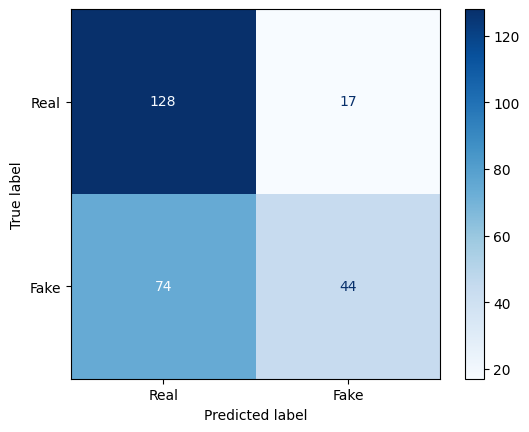

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Filter ground-truth labels present in this dataset
y_true = df_test["LABEL"].values
y_pred = results["Prediction"].map(classifier.reverse_label_map).values

# Only evaluate over classes actually present
present_labels = sorted(np.unique(y_true))
present_names = [classifier.label_map[i] for i in present_labels]

print("Evaluating only classes present in benchmark:", present_names)
print(classification_report(y_true, y_pred, labels=present_labels, target_names=present_names))

cm = confusion_matrix(y_true, y_pred, labels=present_labels)
ConfusionMatrixDisplay(cm, display_labels=present_names).plot(cmap="Blues")


In [30]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_true, y_pred)
print(f"Benchmark accuracy: {acc:.3f}")


Benchmark accuracy: 0.523


Text(0.5, 1.0, 'Probability distribution (benchmark)')

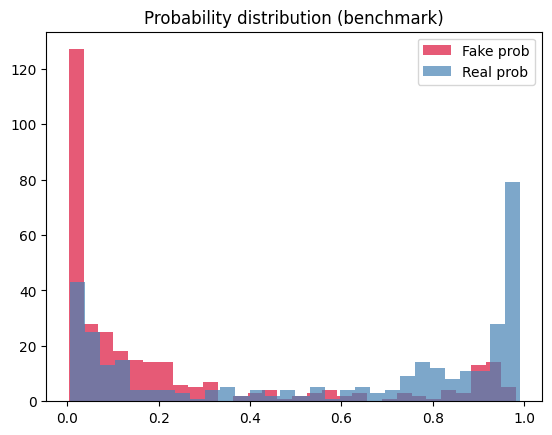

In [31]:
import matplotlib.pyplot as plt
plt.hist(results["Prob_Fake"], bins=30, color="crimson", alpha=.7, label="Fake prob")
plt.hist(results["Prob_Real"], bins=30, color="steelblue", alpha=.7, label="Real prob")
plt.legend(); plt.title("Probability distribution (benchmark)")


In [32]:
print("Train avg len:", df["CORPUS"].str.split().str.len().mean())
print("Test avg len:", df_test["CORPUS"].str.split().str.len().mean())


Train avg len: 436.66580478345185
Test avg len: 505.5258358662614
